# Predicción del ingreso laboral en Bogotá

Se comparan solamente modelos de mínimos cuadrados y ridge, con diferentes variables, transformaciones e interacciones. La selección hacia adelante, hacia atrás y mixta decide grupos de regresores con información de entrenamiento. Los bloques 1-7 ajustan los modelos y los bloques 8-10 determinan el ganador por RMSE, según el enunciado.

In [1]:
from pathlib import Path
import os,sys
ROOT=Path(os.environ.get('PS1_GEIH2018_DIR',Path.cwd())).resolve()
while not (ROOT/'datos/src').is_dir() and ROOT.parent!=ROOT:ROOT=ROOT.parent
sys.path.insert(0,str(ROOT));sys.path.insert(0,str(ROOT/'punto3_prediccion_ingreso/src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Markdown
from src.reportes import tabla,nota_poblacion,alcance
import analisis_lineal as a
plt.rcParams.update({'font.size':11,'axes.titleweight':'normal','axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':.18,'legend.frameon':False})
tr,va=a.cargar()
print(f'Entrenamiento: {len(tr):,}; validación: {len(va):,}')
nota_poblacion(tr,"Entrenamiento de referencias ponderadas")
nota_poblacion(va,"Evaluación ponderada en validación")
tabla(pd.DataFrame([dict(particion=nombre,**alcance(d)) for nombre,d in [("Entrenamiento",tr),("Validación",va)]]),a.SAL/"poblacion_particiones",decimales=0);

Entrenamiento: 10,263; validación: 4,500


Entrenamiento de referencias ponderadas: 10,263 registros; aproximadamente 2,499,677 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

Evaluación ponderada en validación: 4,500 registros; aproximadamente 1,186,729 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

particion,n_muestra,personas_representadas
Entrenamiento,10263,2499677
Validación,4500,1186729


## 1. Pérdida, partición y papel de fex_c
El objetivo es pronosticar $y_i=\log(y_{total,m,i})$. Se minimiza error cuadrático en log-puntos; su minimizador poblacional es $E[y\mid X]$, no $E[\exp(y)\mid X]$.
$$RMSE_V=\sqrt{\frac{1}{n_V}\sum_{i\in V}(y_i-\hat f_T(x_i))^2}.$$
Para esta selección se da el mismo peso a cada registro de validación, conforme al criterio del taller. `fex_c` no se usa como predictor ni para alterar este criterio: ponderarlo cambiaría la población y la función de pérdida que se evalúan. Como sensibilidad se calcula
$$RMSE_{V,w}=\sqrt{\frac{\sum_{i\in V}w_i(y_i-\hat f_T(x_i))^2}{\sum_{i\in V}w_i}},\quad w_i=\texttt{fex\_c}_i,$$
que aproxima error en la población cubierta de Bogotá en vez de error sobre filas. Los modelos terminados en `w` reestiman con `fex_c` las referencias ponderadas de edad y género; los restantes ajustan el riesgo empírico sin pesos. Todos se comparan con ambas métricas, pero se elige por el RMSE sin ponderar requerido.

Los bloques 1-7 contienen 10,263 registros y los bloques 8-10, 4,500; se excluye el mismo caso sin educación de todos los modelos. El mínimo de validación participa en la selección y puede ser optimista: no es un test final independiente.

### Personas representadas y precisión del total
Para el conjunto de registros $G$ utilizado en cada estimación se reportan dos cantidades distintas:
$$n_G=\sum_{i\in G}1,\qquad \widehat N_G=\sum_{i\in G}\texttt{fex\_c}_i.$$
$n_G$ cuenta observaciones y $\widehat N_G$ estima las personas representadas en la escala del archivo. Se suman los factores originales, sin normalizarlos a media uno. Los totales se presentan redondeados a personas; las tablas CSV conservan precisión completa. El total corresponde al grupo efectivamente incluido, no a todos los habitantes de Bogotá.

No se reporta IC del total poblacional: el archivo no suministra estratos de muestreo y unidades primarias identificados como tales, ni pesos replicados o información suficiente de calibración para estimar su varianza de diseño. `estrato1` es estrato socioeconómico y las llaves de hogar no sustituyen esa información. Un IC requeriría $\widehat N_G\pm1.96\widehat{EE}_{diseño}(\widehat N_G)$. La dispersión de los pesos o un bootstrap uniforme de su suma no recuperan por sí solos esa precisión. No disponible no significa incertidumbre cero. [Referencia sobre totales e inferencia de encuestas](https://search.r-project.org/CRAN/refmans/survey/html/surveysummary.html).

Los IC HC1 y bootstrap ya mostrados corresponden a medias, coeficientes o picos bajo la aproximación por personas descrita en el análisis; no son IC de $\widehat N_G$. Los grupos superpuestos y los modelos ajustados a las mismas personas no deben sumarse.

Los totales de entrenamiento y validación son contribuciones de sus registros a la expansión del archivo completo. No son dos estimaciones independientes de toda Bogotá ni se renormalizan para que cada partición represente por sí sola la ciudad. `personas_ajuste_fex_c` queda no aplicable en ajustes sin pesos; `personas_validacion_fex_c` informa la población cubierta por el RMSE ponderado de cada modelo.

## 2. Revisión de todas las variables y prevención de fuga de información
La auditoría recorre todas las columnas de la base tipificada y las variables derivadas de la muestra. Registra disponibilidad en entrenamiento, decisión y motivo. El resultado y sus componentes monetarios, las imputaciones y las alertas construidas a partir del ingreso no entran como predictores. Tampoco entran identificadores de personas, factores de expansión como regresores ni el bloque temporal. Las variables equivalentes se documentan con la representación elegida.

Edad y educación aproximan capital humano; horas y segundo empleo, intensidad laboral; antigüedad, vínculo, formalidad, tamaño y ocupación, características del trabajo; estrato y parentesco, recursos y posición dentro del hogar. Los indicadores laborales adicionales solo son admisibles si están disponibles en la aplicación. Su endogeneidad impide una lectura causal de coeficientes, aunque pueden contener información predictiva.

Los oficios con menos de 20 registros en el ajuste se agrupan en Otros. Categorías, centrado, escala y nudos se aprenden con entrenamiento. Las categorías inéditas de validación se codifican con la referencia aprendida; en oficio se utiliza Otros. La auditoría no selecciona columnas por su correlación con el resultado de validación. Considerar todas las variables no significa introducir todos los campos sin atender a su definición.

In [2]:
auditoria=a.auditar_variables(tr)
tabla(auditoria.groupby('decision').size().rename('variables').reset_index(),a.SAL/'resumen_auditoria')
display(auditoria[['variable','decision','motivo']].style.set_properties(**{'font-weight':'normal'}))

decision,variables
Candidata,23
Evaluación/diseño,3
Excluir,154
No incorporada,8
Representada,20


,variable,decision,motivo
0,fila_en_bloque,Excluir,"Identificador, localización constante o partición temporal; no aprendizaje por llave o mes"
1,directorio,Excluir,"Identificador, localización constante o partición temporal; no aprendizaje por llave o mes"
2,secuencia_p,Excluir,"Identificador, localización constante o partición temporal; no aprendizaje por llave o mes"
3,orden,Excluir,"Identificador, localización constante o partición temporal; no aprendizaje por llave o mes"
4,clase,Excluir,"Identificador, localización constante o partición temporal; no aprendizaje por llave o mes"
5,dominio,Excluir,"Identificador, localización constante o partición temporal; no aprendizaje por llave o mes"
6,mes,Excluir,"Identificador, localización constante o partición temporal; no aprendizaje por llave o mes"
7,estrato1,Representada,Se usa estrato_f
8,sex,Representada,Se usa female
9,age,Candidata,Disponible en el conjunto de especificaciones; ver columnas_modelos.csv


## 3. Especificaciones y estimadores
M0 predice la media de entrenamiento. M1 y M2 usan edad y edad², sin y con horas y vínculo. M3 usa Female. M4 replica S5 aditiva; M4i añade las interacciones Female con edad y edad². M1w-M4iw son sus versiones ponderadas, reestimadas exclusivamente con entrenamiento.

M5 incorpora estrato, jefatura, antigüedad cuadrática y segundo empleo. M6 y M7 permiten polinomios de grados tres y cuatro para edad, horas y antigüedad. M8 utiliza bases cúbicas por tramos con nudos en cuantiles de entrenamiento. Son modelos lineales en coeficientes, aunque sus predicciones no sean lineales en la variable original. M9 incorpora interacciones de sexo, educación y edad, y oficio detallado.

R1 y R2 aplican ridge a los polinomios y a las interacciones. R3 amplía con parentesco, salud, subempleo, horas secundarias, cotización, tamaño e interacciones entre estrato, ocupación, sexo, vínculo, edad y antigüedad. R4 añade años de educación, jornada habitual, cuenta propia e interacciones de escolaridad con edad, formalidad con horas y tamaño con antigüedad. Son alternativas destinadas a capturar rendimientos no constantes y heterogeneidad de perfiles. `columnas_modelos.csv` identifica cada término de cada modelo, incluidas sus variables originales.

Con matriz de diseño $X$, MCO resuelve $\min_b\|y-Xb\|^2$. Ridge resuelve
$$\hat\beta_\lambda=\arg\min_b\left\{\sum_{i\in T}(y_i-x_i'b)^2+\lambda\sum_{j>0}s_j^2b_j^2\right\},$$
donde $s_j$ es la desviación estándar de la columna en entrenamiento y el intercepto no se penaliza. Estandarizar evita que las unidades decidan la intensidad de contracción. La solución usa descomposiciones numéricas estables. Al aumentar $\lambda$ se reduce flexibilidad; el balance entre sesgo y varianza se evalúa mediante predicción fuera de la observación ajustada.

## 4. LOOCV y selección de variables
Para un diseño y una penalización fijos, $\hat y=H_\lambda y$, con
$$H_\lambda=X(X'X+\lambda D)^{-1}X',\quad D=\operatorname{diag}(0,s_1^2,\ldots,s_p^2),$$
$$\hat e_{i,LOO}=\frac{y_i-\hat y_i}{1-h_{ii}},\qquad RMSE_{LOO}=\sqrt{\frac{1}{n_T}\sum_i\hat e_{i,LOO}^2}.$$
Para MCO ponderado, $H_w=X(X'\Omega X)^{-1}X'\Omega$ y se utiliza la misma identidad. La fórmula es exacta cuando se mantienen diseño, escala y penalización al excluir cada fila. Si $h_{ii}=1$, el atajo es indeterminado y se reporta no disponible. No se confunde con una validación que repita selección, centrado y nudos en cada omisión.

Cada ridge selecciona $\lambda$ entre 25 valores logarítmicos de $10^{-2}$ a $10^4$ usando LOOCV en entrenamiento. En R5, R6 y R7 se parte del conjunto amplio de R4 y se mantiene su $\lambda$ mientras se buscan grupos:

1. Hacia adelante (R5): desde intercepto, se añade el grupo que más reduce PRESS.
2. Hacia atrás (R6): desde el conjunto completo, se retira el grupo cuya salida más reduce PRESS.
3. Mixta (R7): desde la solución hacia adelante, se permiten entradas y salidas.

Se detiene cada búsqueda cuando no mejora el RMSE LOO al menos $10^{-7}$. Una interacción se admite solo si están presentes los grupos de sus variables. Después se vuelve a elegir $\lambda$ en el subconjunto retenido. M10 reestima por MCO los grupos elegidos hacia adelante. Las búsquedas son locales, no garantizan el mejor de los $2^G$ subconjuntos ni optimizan conjuntamente todos los $\lambda$. La tabla registra cada paso y las columnas elegidas, sin consultar etiquetas de validación durante la búsqueda.

In [3]:
resultados,comparacion,ganador=a.estimar(tr,va)

Entrenamiento de las referencias ponderadas: 10,263 registros; aproximadamente 2,499,677 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

Evaluación del RMSE ponderado de todos los modelos: 4,500 registros; aproximadamente 1,186,729 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

modelo,ponderado_ajuste,n_entrenamiento,personas_ajuste_fex_c,n_validacion,personas_validacion_fex_c
M0,False,10263,NaN,4500,1186729
M1,False,10263,NaN,4500,1186729
M2,False,10263,NaN,4500,1186729
M3,False,10263,NaN,4500,1186729
M4,False,10263,NaN,4500,1186729
M4i,False,10263,NaN,4500,1186729
M5,False,10263,NaN,4500,1186729
M6,False,10263,NaN,4500,1186729
M7,False,10263,NaN,4500,1186729
M8,False,10263,NaN,4500,1186729


modelo,especificacion,familia,ponderado_ajuste,columnas,gl,lambda_ridge,RMSE_entrenamiento,RMSE_LOOCV,RMSE_validacion,RMSE_validacion_fex_c,seleccionado,n_entrenamiento,n_validacion,personas_ajuste_fex_c,personas_validacion_fex_c
M0,Media de entrenamiento,MCO,False,1,1.0000,0.0000,0.8881,0.8882,0.9151,0.9164,False,10263,4500,NaN,1186728.9804
M1,Edad y edad²,MCO,False,3,3.0000,0.0000,0.8657,0.8660,0.8919,0.8922,False,10263,4500,NaN,1186728.9804
M2,"Edad, horas y vínculo",MCO,False,9,9.0000,0.0000,0.7782,0.7790,0.8118,0.8149,False,10263,4500,NaN,1186728.9804
M3,Brecha sin controles,MCO,False,2,2.0000,0.0000,0.8805,0.8807,0.9066,0.9080,False,10263,4500,NaN,1186728.9804
M4,Controles S5 aditivos,MCO,False,27,27.0000,0.0000,0.5910,0.5928,0.6230,0.6223,False,10263,4500,NaN,1186728.9804
M4i,S5 con perfiles por sexo,MCO,False,29,29.0000,0.0000,0.5904,0.5923,0.6226,0.6218,False,10263,4500,NaN,1186728.9804
M5,Recursos y antigüedad cuadrática,MCO,False,36,36.0000,0.0000,0.5445,0.5469,0.5738,0.5703,False,10263,4500,NaN,1186728.9804
M6,Polinomios cúbicos,MCO,False,39,39.0000,0.0000,0.5386,0.5412,0.5684,0.5639,False,10263,4500,NaN,1186728.9804
M7,Polinomios de grado cuatro,MCO,False,42,42.0000,0.0000,0.5377,0.5405,0.5679,0.5633,False,10263,4500,NaN,1186728.9804
M8,Bases cúbicas por tramos,MCO,False,50,50.0000,0.0000,0.5366,0.5398,0.5674,0.5624,False,10263,4500,NaN,1186728.9804


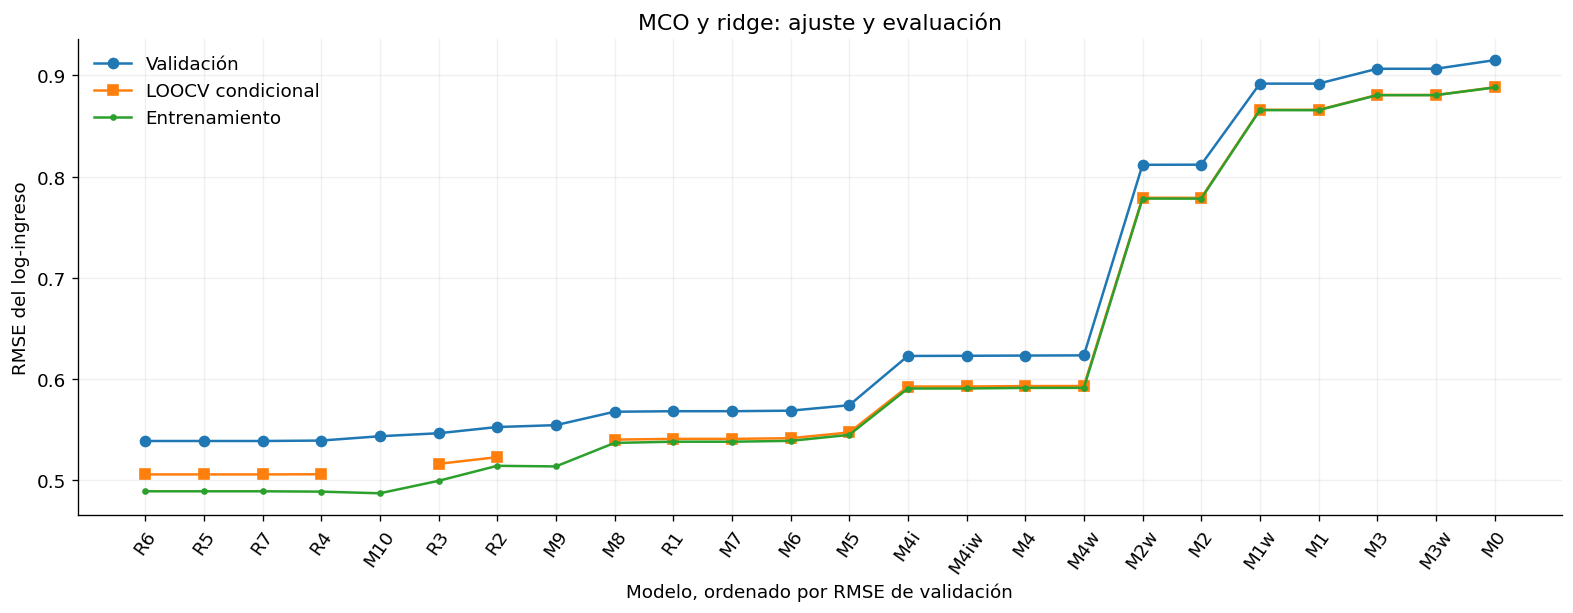

### Selección adelante

,paso,movimiento,grupos,n_columnas,RMSE_LOOCV
0,0,inicio,NaN,1,0.888212
1,1,añadir oficio_f,oficio_f,57,0.736541
2,2,añadir totalHoursWorked,oficio_f|totalHoursWorked,64,0.641101
3,3,añadir anios_educ,anios_educ|oficio_f|totalHoursWorked,66,0.598482
4,4,añadir formal,anios_educ|formal|oficio_f|totalHoursWorked,74,0.574974
5,5,añadir estrato_f,anios_educ|estrato_f|formal|oficio_f|totalHour...,79,0.553039
6,6,añadir relab_f,anios_educ|estrato_f|formal|oficio_f|relab_f|t...,119,0.542741
7,7,añadir age,age|anios_educ|estrato_f|formal|oficio_f|relab...,168,0.533364
8,8,añadir sizeFirm_f,age|anios_educ|estrato_f|formal|oficio_f|relab...,172,0.524546
9,9,añadir antiguedad_anios,age|anios_educ|antiguedad_anios|estrato_f|form...,216,0.517146


### Selección atras

,paso,movimiento,grupos,n_columnas,RMSE_LOOCV
0,0,inicio,age|anios_educ|antiguedad_anios|cotiza_pension...,347,0.505559
1,1,retirar segundo_empleo,age|anios_educ|antiguedad_anios|cotiza_pension...,346,0.505493
2,2,retirar terciaria,age|anios_educ|antiguedad_anios|cotiza_pension...,340,0.505458
3,3,retirar horas_segundo_empleo,age|anios_educ|antiguedad_anios|cotiza_pension...,339,0.505444
4,4,retirar hoursWorkUsual,age|anios_educ|antiguedad_anios|cotiza_pension...,338,0.505400


### Selección mixto

,paso,movimiento,grupos,n_columnas,RMSE_LOOCV
0,0,inicio,age|anios_educ|antiguedad_anios|cotiza_pension...,337,0.5054


In [4]:
a.comparar(comparacion)
for metodo in ['adelante','atras','mixto']:
    display(Markdown('### Selección '+metodo))
    display(pd.read_csv(a.SAL/f'seleccion_{metodo}.csv'))

## 5. Selección final y validación del ganador
La regla es $\hat m=\arg\min_m RMSE_V(m)$ sobre todas las filas de la tabla, incluidas referencias, variantes ponderadas y métodos de selección. La métrica ponderada se informa como sensibilidad y no cambia esa regla.

Se compara el LOO condicional del ganador con validación y con cinco pliegues que reconstruyen categorías, nudos y escala y renuevan $\lambda$. Estos pliegues mantienen el conjunto de variables del ganador; no se denominan validación anidada porque no vuelven a efectuar toda la selección de grupos y familia. Su error agrupa todas las predicciones externas antes de extraer la raíz. Las diferencias de error no identifican por sí solas deriva temporal ni ausencia de sobreajuste.

In [5]:
cv=a.validar(tr,va,resultados[ganador])

Población cubierta por la sensibilidad del RMSE con fex_c: 4,500 registros; aproximadamente 1,186,729 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

medida,RMSE
LOOCV condicional,0.5054
"CV 5, transformaciones y lambda renovadas; grupos fijos",0.5501
Validación bloques 8-10,0.5384


## 6. Importancia de variables
La importancia se define para el modelo ganador ya ajustado. Para cada variable original $j$, se permutan sus valores entre filas de validación y se reconstruyen todas las transformaciones e interacciones que la contienen. Se conserva el modelo fijo:
$$I_j=\frac{1}{B}\sum_{b=1}^B\left[RMSE\{y_V,\hat f_T(X_V^{\pi_b(j)})\}-RMSE\{y_V,\hat f_T(X_V)\}\right],\quad B=30.$$
Un aumento grande indica que romper la asociación entre esa variable y las personas perjudica la predicción. Es preferible a ordenar coeficientes absolutos cuando hay escalas distintas, categorías y potencias. La desviación de los 30 sorteos mide variación Monte Carlo; no es un error estándar muestral de importancia.

Como contraste se elimina la variable y todas las columnas que dependen de ella, se vuelven a ajustar coeficientes y $\lambda$, y se calcula
$$J_j=RMSE_V(\hat f_{-j})-RMSE_V(\hat f).$$
Esta medida pregunta cuánto puede compensar el resto de variables su ausencia. Por eso puede diferir de $I_j$: educación en años y niveles, o jornadas total y habitual, pueden sustituirse. Los valores negativos son posibles; no prueban un efecto económico negativo. Ambas medidas dependen del universo candidato, correlaciones y selección en validación, y no son efectos causales.

El perfil de respuesta de la variable principal se calcula como $\hat m_j(z)=n_V^{-1}\sum_{i\in V}\hat f_T(z,x_{i,-j})$. Se varía entre los percentiles 5 y 95 si es numérica, o entre sus categorías observadas, manteniendo los demás atributos fijos. Es un promedio del log-ingreso predicho; las combinaciones artificiales pueden tener poco soporte conjunto.

variable,delta_RMSE_validacion,sd_permutaciones,delta_RMSE_reajuste
totalHoursWorked,0.1072,0.0041,0.0405
anios_educ,0.0978,0.0039,0.0052
oficio_grupo,0.0736,0.0035,0.0011
estrato_f,0.0639,0.0036,0.0215
oficio_f,0.0396,0.0018,0.0063
relab_f,0.0376,0.0056,0.0063
sizeFirm_f,0.0243,0.0017,0.0020
antiguedad_anios,0.0230,0.0028,0.0100
age,0.0225,0.0025,0.0063
female,0.0147,0.0020,0.0029


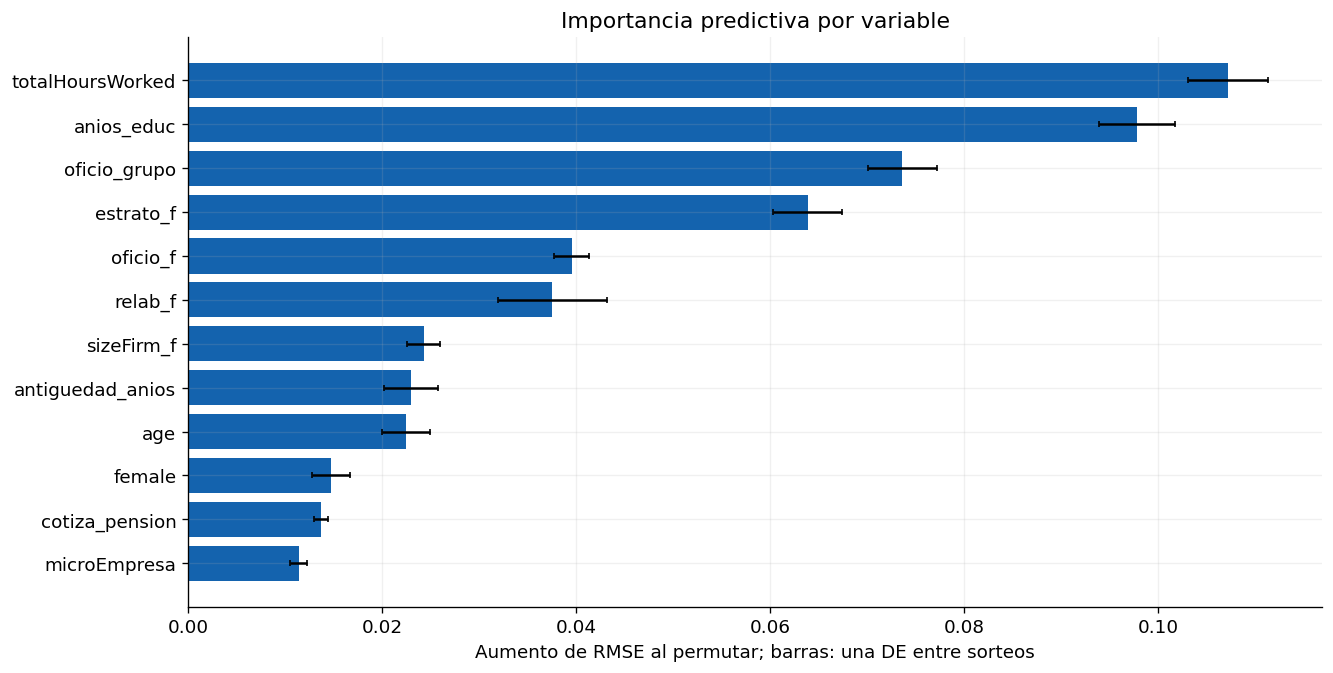

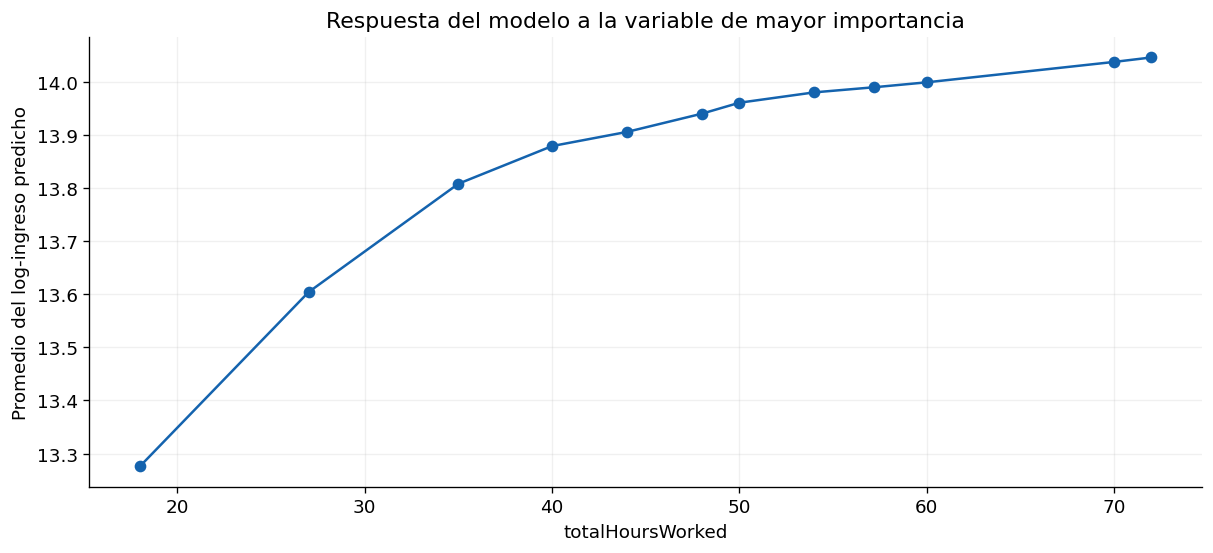

In [6]:
importancia,perfil=a.importancia(tr,va,resultados[ganador])

## 7. Resultados y límites de uso

In [7]:
resumen=a.resumen(tr,va,comparacion,ganador,cv,importancia)
r=comparacion.loc[comparacion.modelo==ganador].iloc[0]
ref=comparacion.loc[comparacion.modelo=='M2w','RMSE_validacion'].iloc[0]
mejora=100*(1-r.RMSE_validacion/ref)
cv5=cv.loc[cv.medida.str.startswith('CV 5'),'RMSE'].iloc[0]
ventaja=comparacion.RMSE_validacion.nsmallest(2).iloc[1]-r.RMSE_validacion
display(Markdown(f'''El ganador entre {len(comparacion)} especificaciones es {ganador}: {r.especificacion}. Su RMSE de validación es {r.RMSE_validacion:.4f} log-puntos, frente a {ref:.4f} del perfil básico de edad, horas y vínculo ponderado (M2w), una reducción relativa de {mejora:.1f}%. El RMSE LOOCV condicional es {r.RMSE_LOOCV:.4f}; el RMSE de validación ponderado por fex_c es {r.RMSE_validacion_fex_c:.4f}.

La CV de cinco pliegues, con transformaciones y penalización renovadas pero grupos fijos, obtiene RMSE {cv5:.4f}. El LOO condicional evalúa un procedimiento más restringido y no reemplaza esta comprobación. La ventaja sobre el segundo candidato es apenas {ventaja:.6f} log-puntos: la regla elige un ganador numérico, pero esta diferencia no demuestra superioridad estadística.

La variable con mayor importancia por permutación es `{importancia.iloc[0].variable}`, con aumento medio de RMSE de {importancia.iloc[0].delta_RMSE_validacion:.4f}. Su importancia incremental al eliminarla y reajustar es {importancia.iloc[0].delta_RMSE_reajuste:.4f}; la diferencia entre ambas medidas muestra el papel de la sustitución entre predictores.

La comparación respalda usar información de capital humano y condiciones laborales más flexible que los perfiles iniciales. La regularización y la selección deben juzgarse por su error predictivo, no por el R² de entrenamiento. El ganador corresponde al universo MCO/ridge estudiado y al criterio de validación fijado; no se afirma optimalidad universal.

Como validación participa en la selección, un uso posterior requeriría otra muestra independiente y verificar disponibilidad de los regresores. Los pesos de expansión modifican qué población representa el error, pero no corrigen por sí solos la no respuesta del ingreso. Para una autoridad tributaria, una diferencia entre ingreso observado y pronosticado solo constituye una discrepancia que necesita corroboración; este ejercicio no observa ingreso verdadero ni identifica evasión individual.'''))

El ganador entre 24 especificaciones es R6: Ridge, selección atras. Su RMSE de validación es 0.5384 log-puntos, frente a 0.8116 del perfil básico de edad, horas y vínculo ponderado (M2w), una reducción relativa de 33.7%. El RMSE LOOCV condicional es 0.5054; el RMSE de validación ponderado por fex_c es 0.5342.

La CV de cinco pliegues, con transformaciones y penalización renovadas pero grupos fijos, obtiene RMSE 0.5501. El LOO condicional evalúa un procedimiento más restringido y no reemplaza esta comprobación. La ventaja sobre el segundo candidato es apenas 0.000010 log-puntos: la regla elige un ganador numérico, pero esta diferencia no demuestra superioridad estadística.

La variable con mayor importancia por permutación es `totalHoursWorked`, con aumento medio de RMSE de 0.1072. Su importancia incremental al eliminarla y reajustar es 0.0405; la diferencia entre ambas medidas muestra el papel de la sustitución entre predictores.

La comparación respalda usar información de capital humano y condiciones laborales más flexible que los perfiles iniciales. La regularización y la selección deben juzgarse por su error predictivo, no por el R² de entrenamiento. El ganador corresponde al universo MCO/ridge estudiado y al criterio de validación fijado; no se afirma optimalidad universal.

Como validación participa en la selección, un uso posterior requeriría otra muestra independiente y verificar disponibilidad de los regresores. Los pesos de expansión modifican qué población representa el error, pero no corrigen por sí solos la no respuesta del ingreso. Para una autoridad tributaria, una diferencia entre ingreso observado y pronosticado solo constituye una discrepancia que necesita corroboración; este ejercicio no observa ingreso verdadero ni identifica evasión individual.

## Referencias

- [Clase 4: validación cruzada](https://github.com/ignaciomsarmiento/BDML_2026_20/tree/main/Lecture04).
- [Clase 5: ridge](https://github.com/ignaciomsarmiento/BDML_2026_20/tree/main/Lecture05).
- Secciones complementarias del curso sobre diagnósticos, ridge y estimación del error fuera de muestra.
- [Documentación de scikit-learn sobre fuga de información](https://scikit-learn.org/1.7/common_pitfalls.html).

Las tablas se conservan con precisión completa en CSV y se exportan como LaTeX. El texto y las cifras del resumen se generan con los resultados de la ejecución.